In [2]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define dataset path
dataset_path = "/content/drive/MyDrive/dataset1"  # Update path if needed

# Check if dataset exists
if not os.path.exists(dataset_path):
    raise FileNotFoundError("Dataset not found! Check the path in Google Drive.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 846.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjit

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import shutil


Add data augmentation (rotation, flip, brightness changes) to improve generalization

In [5]:
transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


Load Dataset & Remove Checkpoints
python
Copy
Edit


In [6]:
# Remove .ipynb_checkpoints if exists
checkpoint_dir = os.path.join(dataset_path, ".ipynb_checkpoints")
if os.path.exists(checkpoint_dir):
    shutil.rmtree(checkpoint_dir)

# Load dataset
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

# Split into Training (80%) and Validation (20%)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

print("✅ Dataset Loaded Successfully!")


✅ Dataset Loaded Successfully!


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Load Pretrained RegNetX-16GF & Add Advanced Layers

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load RegNetX-16GF Model
model = models.regnet_x_16gf(weights="IMAGENET1K_V2")
num_ftrs = model.fc.in_features

# 🔥 ADVANCED LAYER: Custom Fully Connected Layers 🔥
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 4)  # 4 classes: Benign, Malignant Early Pre-B, Malignant Pre-B, Malignant Pro-B
)

model = model.to(device)
print("✅ Model Loaded with Advanced Layers!")


Downloading: "https://download.pytorch.org/models/regnet_x_16gf-ba3796d7.pth" to /root/.cache/torch/hub/checkpoints/regnet_x_16gf-ba3796d7.pth
100%|██████████| 208M/208M [00:04<00:00, 54.4MB/s]


✅ Model Loaded with Advanced Layers!


Define Loss Function & Optimizer

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)


Train the Model

In [10]:
!pip install tqdm


In [11]:
from tqdm import tqdm


In [12]:
num_epochs = 10

train_losses, train_accuracies, val_accuracies = [], [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    # Add tqdm progress bar
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Update tqdm progress bar
        progress_bar.set_postfix(loss=loss.item(), acc=100 * correct / total)

    train_acc = 100 * correct / total
    avg_loss = running_loss / len(train_loader)

    train_losses.append(avg_loss)
    train_accuracies.append(train_acc)

    # Step LR scheduler
    scheduler.step()

    print(f"✅ Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Train Acc: {train_acc:.2f}%")

    # Validation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100 * correct / total
    val_accuracies.append(val_acc)

    print(f"✅ Validation Accuracy: {val_acc:.2f}%")

print("🔥 Training Complete!")


✅ Epoch [1/10], Loss: 0.2268, Train Acc: 93.64%


✅ Validation Accuracy: 87.54%


✅ Epoch [2/10], Loss: 0.2451, Train Acc: 91.72%


✅ Validation Accuracy: 96.15%


✅ Epoch [3/10], Loss: 0.1629, Train Acc: 95.07%


...

✅ Validation Accuracy: 98.46%


✅ Epoch [9/10], Loss: 0.0569, Train Acc: 98.34%


✅ Validation Accuracy: 98.31%


✅ Epoch [10/10], Loss: 0.0752, Train Acc: 97.92%


✅ Validation Accuracy: 99.08%
🔥 Training Complete!


In [13]:
torch.save(model.state_dict(), "/content/drive/MyDrive/RegNetX_Advanced.pth")
print("✅ Model Saved Successfully!")


✅ Model Saved Successfully!


CM

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


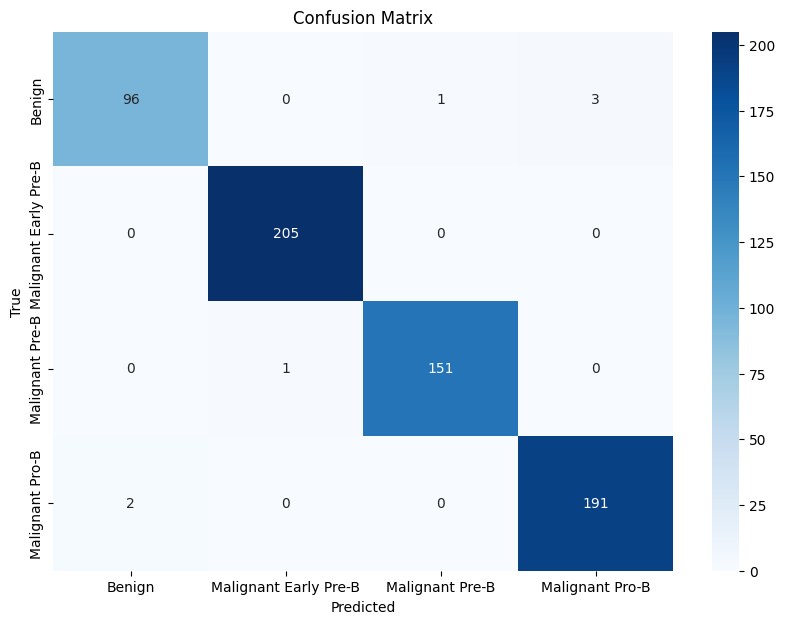

In [15]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Generate confusion matrix
def plot_confusion_matrix(model, data_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Assuming `val_loader` is the validation DataLoader and `model` is your trained model
class_names = ['Benign', 'Malignant Early Pre-B', 'Malignant Pre-B', 'Malignant Pro-B']
plot_confusion_matrix(model, val_loader, device, class_names)


Loss Curve – Training vs. validation loss over epochs

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


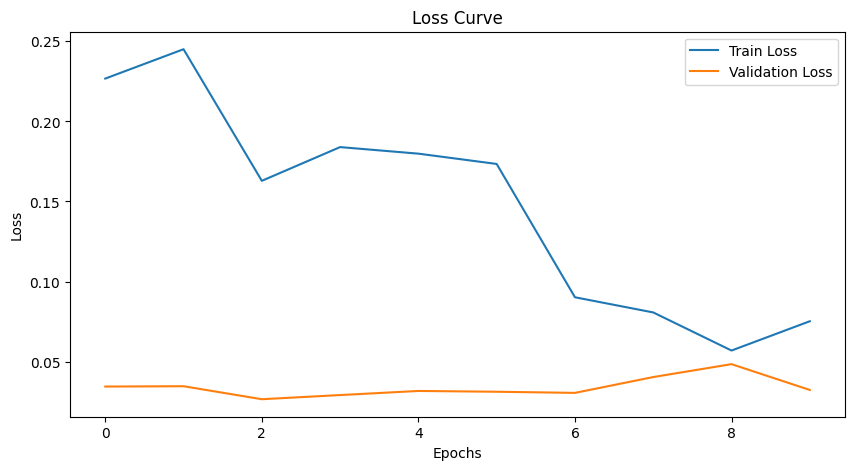

In [16]:
# Plot loss curve
def plot_loss_curve(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Store validation losses during training and plot
val_losses = []
for epoch in range(num_epochs):
    # Calculate validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

# Call the plot function
plot_loss_curve(train_losses, val_losses)


Accuracy Curve – Training vs. validation accuracy over epochs.

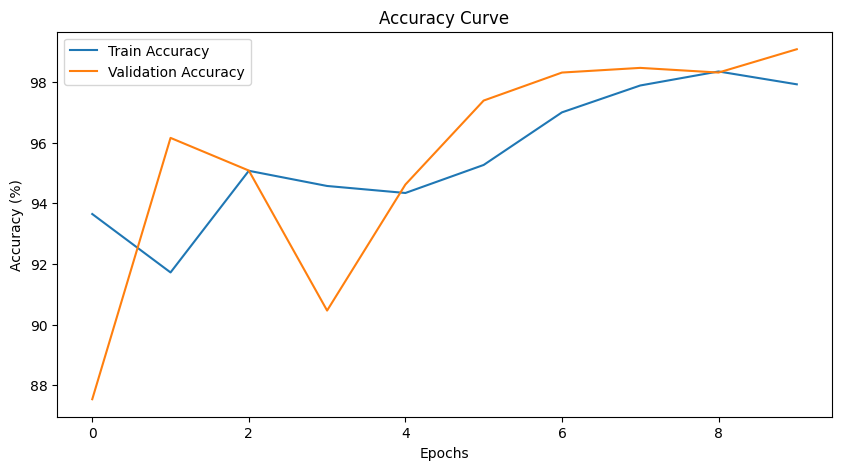

In [17]:
# Plot accuracy curve
def plot_accuracy_curve(train_accuracies, val_accuracies):
    plt.figure(figsize=(10, 5))
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.title('Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.show()

# Call the plot function
plot_accuracy_curve(train_accuracies, val_accuracies)


Class Distribution – Distribution of images in each class.

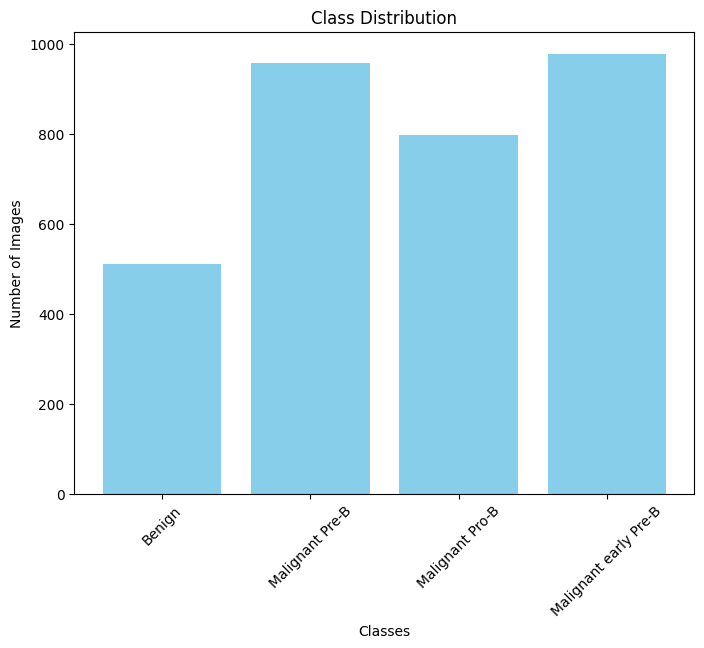

In [18]:
# Plot class distribution
def plot_class_distribution(dataset):
    class_counts = [0] * len(dataset.classes)
    for _, label in dataset:
        class_counts[label] += 1

    plt.figure(figsize=(8, 6))
    plt.bar(dataset.classes, class_counts, color='skyblue')
    plt.title('Class Distribution')
    plt.xlabel('Classes')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45)
    plt.show()

# Call the plot function
plot_class_distribution(dataset)


Precision, Recall & F1-Score Bar Chart – Evaluates model performance per class.

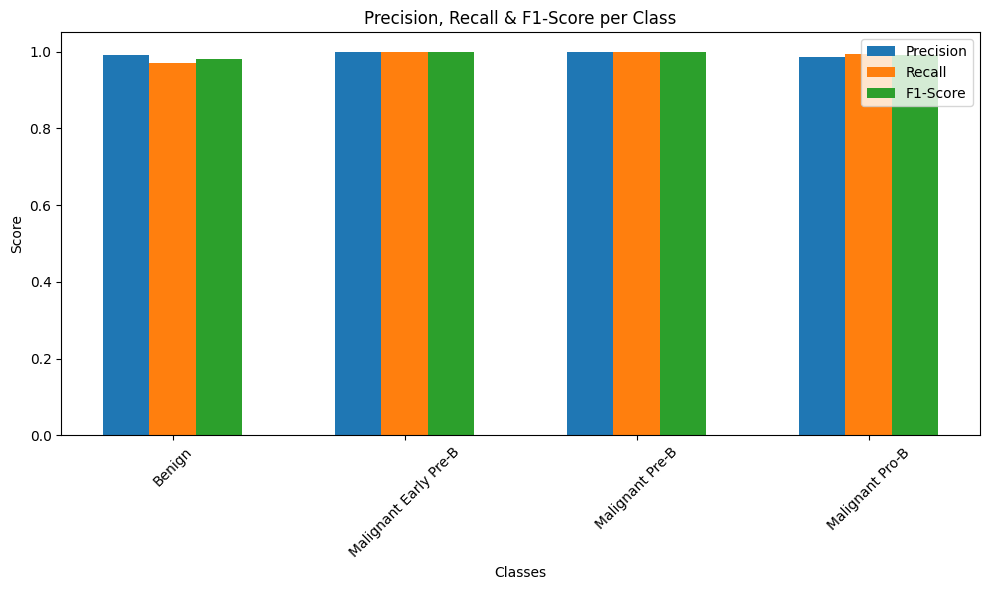

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Generate metrics for each class
def plot_class_metrics(model, data_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    precision = precision_score(all_labels, all_preds, average=None)
    recall = recall_score(all_labels, all_preds, average=None)
    f1 = f1_score(all_labels, all_preds, average=None)

    # Plotting bar chart for precision, recall, and F1-score
    x = np.arange(len(class_names))
    width = 0.2  # Bar width

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width, precision, width, label='Precision')
    ax.bar(x, recall, width, label='Recall')
    ax.bar(x + width, f1, width, label='F1-Score')

    ax.set_xlabel('Classes')
    ax.set_ylabel('Score')
    ax.set_title('Precision, Recall & F1-Score per Class')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45)
    ax.legend()

    plt.tight_layout()
    plt.show()

# Call the plot function
plot_class_metrics(model, val_loader, device, class_names)


ROC Curve (Receiver Operating Characteristic) – AUC scores for class-wise performance.

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


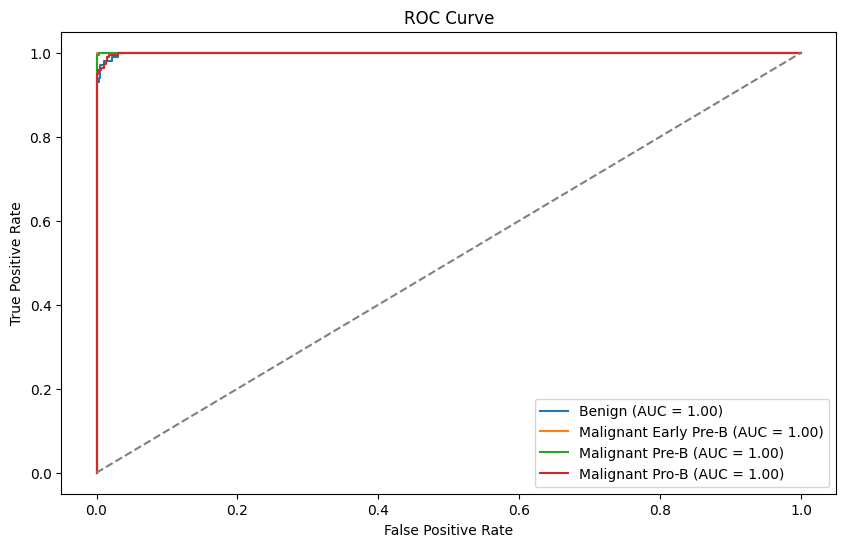

In [20]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Plot ROC curve for each class
def plot_roc_curve(model, data_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            all_preds.append(outputs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    all_labels_bin = label_binarize(all_labels, classes=np.arange(len(class_names)))

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_preds[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curve for all classes
    plt.figure(figsize=(10, 6))
    for i in range(len(class_names)):
        plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

# Call the plot function
plot_roc_curve(model, val_loader, device, class_names)


In [23]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Generate metrics for each class
def evaluate_model_performance(model, data_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []  # To store probabilities for AUC calculation

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)  # Get probabilities
            _, preds = torch.max(outputs, 1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())  # Store probabilities

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)

    # Calculate metrics for each class
    precision = precision_score(all_labels, all_preds, average=None)
    recall = recall_score(all_labels, all_preds, average=None)
    f1 = f1_score(all_labels, all_preds, average=None)

    # Binarize the labels for multi-class AUC
    all_labels_bin = label_binarize(all_labels, classes=np.arange(len(class_names)))

    # Calculate AUC for each class
    auc = roc_auc_score(all_labels_bin, all_probs, average=None, multi_class='ovr')

    # Create a DataFrame to display results
    results = {
        'Class': class_names,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC': auc
    }

    performance_df = pd.DataFrame(results)
    performance_df = performance_df.round(4)  # Round results for better readability

    return performance_df

# Assuming `val_loader` is the validation DataLoader and `model` is your trained model
performance_df = evaluate_model_performance(model, val_loader, device, class_names)

# Display the performance table
print(performance_df)


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


                   Class  Precision  Recall  F1-Score     AUC
0                 Benign     0.9899  0.9800    0.9849  0.9998
1  Malignant Early Pre-B     1.0000  0.9854    0.9926  0.9999
2        Malignant Pre-B     1.0000  1.0000    1.0000  1.0000
3        Malignant Pro-B     0.9746  0.9948    0.9846  0.9996
